# Analiza

In [224]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie do obliczeń: {device}")

Używane urządzenie do obliczeń: cuda


In [225]:
IMG_SIZE = 224
data_dir = './Waste-Classification-1'


In [226]:
temp_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

temp_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'train'),
    transform=temp_transforms
)

temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=2)

mean = torch.zeros(3)
std  = torch.zeros(3)
total = 0

for images, _ in temp_loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total += batch_size

mean /= total
std  /= total

print(f"Mean: {mean}")
print(f"Std:  {std}")

means = mean.tolist()
stds = std.tolist()

Mean: tensor([0.6722, 0.6394, 0.6053])
Std:  tensor([0.1791, 0.1782, 0.1887])


In [227]:
data_transforms = {
    'train': transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(means, stds)
    ]),
    'valid': transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 256/224)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(means, stds)
    ]),
    'test': transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 256/224)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(means, stds)
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'valid', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2, pin_memory=True)
    for x in ['train', 'valid', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

for split in ['train', 'valid', 'test']:
    targets = image_datasets[split].targets
    print(f"{split} ({dataset_sizes[split]}):")
    for i, name in enumerate(class_names):
        print(f"  {name}: {targets.count(i)} ({targets.count(i) / dataset_sizes[split] * 100:.1f}%)")
    print()

train (1767):
  cardboard: 275 (15.6%)
  glass: 352 (19.9%)
  metal: 284 (16.1%)
  paper: 423 (23.9%)
  plastic: 340 (19.2%)
  trash: 93 (5.3%)

valid (504):
  cardboard: 84 (16.7%)
  glass: 102 (20.2%)
  metal: 85 (16.9%)
  paper: 107 (21.2%)
  plastic: 96 (19.0%)
  trash: 30 (6.0%)

test (253):
  cardboard: 44 (17.4%)
  glass: 47 (18.6%)
  metal: 40 (15.8%)
  paper: 64 (25.3%)
  plastic: 44 (17.4%)
  trash: 14 (5.5%)



# Definiowanie Modelu

In [228]:
class NikTechTrashClassificationCnn(nn.Module):
    def __init__(self, num_classes, img_size):
        super(NikTechTrashClassificationCnn, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        fc1_size = 256 * (img_size // 16) * (img_size // 16)
        self.fc1 = nn.Linear(fc1_size, 512)
        self.bn5 = nn.BatchNorm1d(512)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class_count = len(class_names)

model = NikTechTrashClassificationCnn(num_classes=class_count, img_size=IMG_SIZE).to(device)

print(model)
print(f"\nModel pomyślnie załadowany na urządzenie: {device}")

NikTechTrashClassificationCnn(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (bn5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_

# Pętla treningowa

In [229]:
#HIPERPARAMETRY
NUM_EPOCHS = 120
LEARNING_RATE = 0.001

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        pt = torch.exp(-ce_loss)
        
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
class_counts  = [image_datasets['train'].targets.count(i) for i in range(class_count)]

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(dataloaders['train'])
)

In [232]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  []
}

best_val_acc    = 0.0
best_model_path =  'best_model.pth'
patience_counter = 0
early_stop_patience = 20

In [233]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc



In [234]:
training_start = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        model, dataloaders['train'], criterion, optimizer, device, scheduler
    )

    val_loss, val_acc = validate_epoch(
        model, dataloaders['valid'], criterion, device
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Trening: Loss {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"Walidacja: Loss: {val_loss:.4f}  | Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch':           epoch + 1,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc':         best_val_acc,
            'class_names':     class_names,
            'img_size':        IMG_SIZE,
        }, best_model_path)
        print(f"Najlepszy model zapisany (acc: {best_val_acc*100:.2f}%)")
    else:
        patience_counter += 1
        print(f"Brak poprawy ({patience_counter}/{early_stop_patience})")
        if patience_counter >= early_stop_patience:
            print("Zatrzymanie")
            break

total_time = time.time() - training_start

print("\n" + "=" * 60)
print(f"Training skończony, najlepsza dokładnosc na zbiorze walidacyjnym: {best_val_acc*100:.2f}%")
print(f"Czas trenowania: {total_time//60:.0f}m {total_time%60:.0f}s")
print("=" * 60)


Epoch [1/120]
----------------------------------------
  Batch [10/56] Loss: 0.9687
  Batch [20/56] Loss: 0.9331
  Batch [30/56] Loss: 0.7392
  Batch [40/56] Loss: 0.7729
  Batch [50/56] Loss: 0.6999
Trening: Loss 0.8963 | Acc: 48.22%
Walidacja: Loss: 0.5560  | Acc: 61.71%
Najlepszy model zapisany (acc: 61.71%)

Epoch [2/120]
----------------------------------------
  Batch [10/56] Loss: 0.6050
  Batch [20/56] Loss: 0.6911
  Batch [30/56] Loss: 0.6283
  Batch [40/56] Loss: 0.7499
  Batch [50/56] Loss: 0.6690
Trening: Loss 0.7130 | Acc: 57.44%
Walidacja: Loss: 0.4395  | Acc: 71.43%
Najlepszy model zapisany (acc: 71.43%)

Epoch [3/120]
----------------------------------------
  Batch [10/56] Loss: 0.7026
  Batch [20/56] Loss: 0.4929
  Batch [30/56] Loss: 0.4980
  Batch [40/56] Loss: 0.5544
  Batch [50/56] Loss: 0.5870
Trening: Loss 0.5994 | Acc: 60.72%
Walidacja: Loss: 0.4395  | Acc: 71.43%
Brak poprawy (1/20)

Epoch [4/120]
----------------------------------------
  Batch [10/56] Loss:

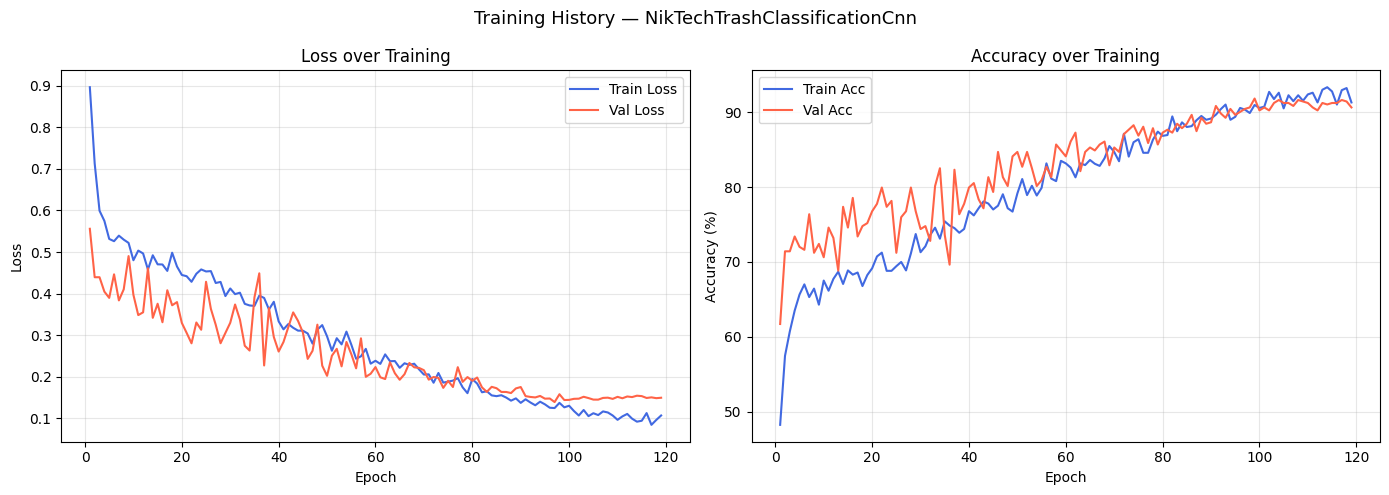

In [235]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss over Training')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy over Training')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — NikTechTrashClassificationCnn', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Weryfikacja ze zbiorem testowym


In [236]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val acc: {checkpoint['val_acc']*100:.2f}%)")

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in dataloaders['test']:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Loaded best model from epoch 99 (val acc: 91.87%)


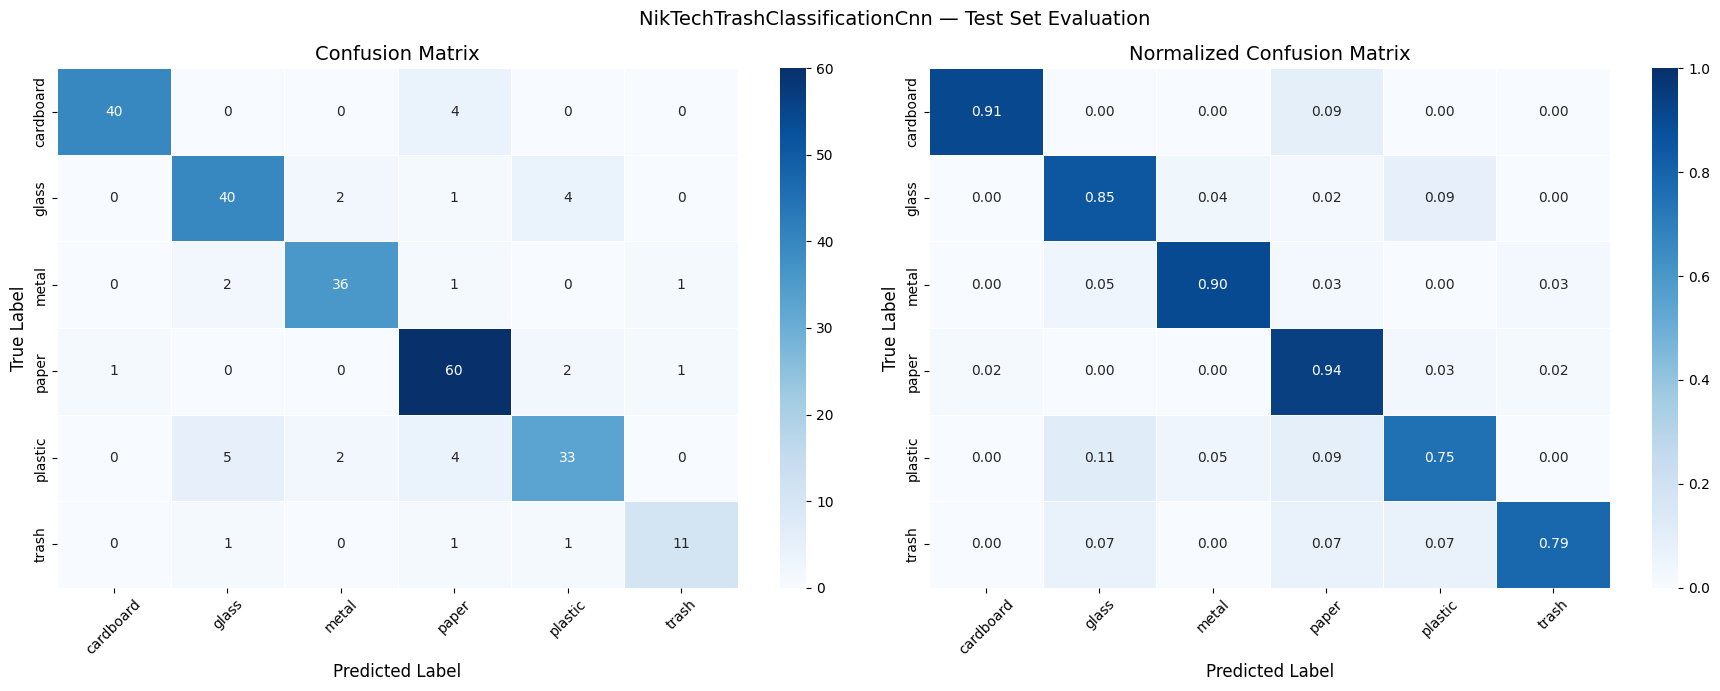

              precision    recall  f1-score   support

   cardboard     0.9756    0.9091    0.9412        44
       glass     0.8333    0.8511    0.8421        47
       metal     0.9000    0.9000    0.9000        40
       paper     0.8451    0.9375    0.8889        64
     plastic     0.8250    0.7500    0.7857        44
       trash     0.8462    0.7857    0.8148        14

    accuracy                         0.8696       253
   macro avg     0.8709    0.8556    0.8621       253
weighted avg     0.8708    0.8696    0.8690       253

Dokładność względem zbioru testowego 86.96%


In [237]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NikTechTrashClassificationCnn — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
print(f"Dokładność względem zbioru testowego {(all_labels == all_preds).mean()*100:.2f}%")

Wnioski

    Rozmiar obrazu: Najlepsze wyniki klasyfikacji osiągnięto dla wejścia o rozmiarze 224x224 pikseli.

    Augmentacja: Większość transformacji pogarszała wyniki. Skuteczny okazał się jedynie RandomResizedCrop, zmuszający model do nauki lokalnej tekstury zamiast zniekształconego kształtu śmieci.

    Weighted Loss: Użycie wag klas obniżyło ogólne Accuracy, co jest naturalnym paradoksem – model przestał faworyzować najliczniejszą klasę na rzecz rzadszych odpadów.

    BatchNorm: Warstwy normalizacji wsadowej okazały się kluczowe dla ustabilizowania treningu sieci budowanej całkowicie od zera.

    Optymalizacja: Wykorzystanie optymalizatora AdamW wraz z harmonogramem OneCycleLR zapewniło szybką i efektywną zbieżność.

    Early Stopping: Mechanizm ten zadziałał poprawnie, zapisując optymalne wagi i skutecznie chroniąc model przed przeuczeniem.